# DATATHON 2026 Round 1
## Part 2 - Visualization and Data Analysis

**Team:** `<CT-PTIT/> CapyData`

This notebook is prepared for **Part 2 - Trực quan hoá và Phân tích Dữ liệu** of Round 1. Following the exam requirement, each section combines a visualization with a short analysis of what the chart shows, why it matters, the key numerical findings, and the business implication.

The analysis is organized around the four evaluation levels in the prompt:

- **Descriptive:** summarize what happened in the data.
- **Diagnostic:** compare groups and identify possible drivers.
- **Predictive:** use seasonality, trends, and proxy indicators to discuss what may happen next.
- **Prescriptive:** propose actions supported by the observed metrics.

We focus on six business questions for a fashion e-commerce company:

1. How did revenue and gross margin change over time?
2. Which product categories and segments contribute the most to profitable growth?
3. Are promotions creating healthy revenue or eroding margin?
4. Where do returns, delivery issues, and customer satisfaction create business risk?
5. Which traffic sources show stronger engagement and conversion potential?
6. Which inventory groups face stockout or overstock risk?


In [ ]:
# Required packages: pandas, numpy, matplotlib, seaborn
# Uncomment the next line only if the environment does not have these packages
# %pip install pandas numpy matplotlib seaborn

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('.')
FIG_DIR = Path('eda_figures')
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 1. Data Loading

Các file được chia thành 4 nhóm: master, transaction, analytical và operational. Notebook sử dụng các bảng này để tạo biểu đồ và phân tích các pattern, xu hướng và mối quan hệ trong dữ liệu theo yêu cầu của đề.

In [16]:
products = pd.read_csv(DATA_DIR / 'products.csv')
customers = pd.read_csv(DATA_DIR / 'customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography = pd.read_csv(DATA_DIR / 'geography.csv')

orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv')
payments = pd.read_csv(DATA_DIR / 'payments.csv')
shipments = pd.read_csv(DATA_DIR / 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv(DATA_DIR / 'reviews.csv', parse_dates=['review_date'])

sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
web = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])

summary = pd.DataFrame({
    'table': ['products','customers','promotions','geography','orders','order_items','payments','shipments','returns','reviews','sales','inventory','web_traffic'],
    'rows': [len(products), len(customers), len(promotions), len(geography), len(orders), len(order_items), len(payments), len(shipments), len(returns), len(reviews), len(sales), len(inventory), len(web)],
    'columns': [products.shape[1], customers.shape[1], promotions.shape[1], geography.shape[1], orders.shape[1], order_items.shape[1], payments.shape[1], shipments.shape[1], returns.shape[1], reviews.shape[1], sales.shape[1], inventory.shape[1], web.shape[1]]
})
display(summary)

,table,rows,columns
0,products,2412,8
1,customers,121930,7
2,promotions,50,10
3,geography,39948,4
4,orders,646945,8
5,order_items,714669,7
6,payments,646945,4
7,shipments,566067,4
8,returns,39939,7
9,reviews,113551,7


## 2. Item-Level Analytical Table

Bảng `df` là nền tảng cho phần lớn phân tích: mỗi dòng là một sản phẩm trong một đơn hàng, được nối với thông tin sản phẩm, đơn hàng, địa lý, thanh toán, giao vận, trả hàng và review. Từ bảng này, notebook tạo các chỉ số như net revenue, gross profit, margin, discount rate, delivery time và return rate.

In [17]:
def safe_divide(num, den):
    return np.where(den == 0, np.nan, num / den)

orders_geo = orders.merge(geography, on='zip', how='left')

return_agg = returns.groupby(['order_id', 'product_id'], as_index=False).agg(
    returned_qty=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum'),
    return_records=('return_id', 'count')
)

review_agg = reviews.groupby(['order_id', 'product_id'], as_index=False).agg(
    avg_rating=('rating', 'mean'),
    review_count=('review_id', 'count')
)

df = (
    order_items
    .merge(products, on='product_id', how='left')
    .merge(orders_geo, on='order_id', how='left')
    .merge(payments[['order_id', 'payment_value', 'installments']], on='order_id', how='left')
    .merge(shipments, on='order_id', how='left')
    .merge(return_agg, on=['order_id', 'product_id'], how='left')
    .merge(review_agg, on=['order_id', 'product_id'], how='left')
)

for col in ['returned_qty', 'refund_amount', 'return_records', 'review_count']:
    df[col] = df[col].fillna(0)

df['gross_revenue'] = df['quantity'] * df['unit_price']
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']
df['line_cogs'] = df['quantity'] * df['cogs']
df['gross_profit'] = df['net_revenue'] - df['line_cogs']
df['gross_margin_rate'] = safe_divide(df['gross_profit'], df['net_revenue'])
df['discount_rate'] = safe_divide(df['discount_amount'], df['gross_revenue'])
df['return_flag'] = (df['returned_qty'] > 0).astype(int)
df['return_rate_qty'] = safe_divide(df['returned_qty'], df['quantity'])
df['has_promo'] = df['promo_id'].notna() & (df['promo_id'].astype(str).str.len() > 0)
df['has_second_promo'] = df['promo_id_2'].notna() & (df['promo_id_2'].astype(str).str.len() > 0)
df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)
df['weekday'] = df['order_date'].dt.day_name()

print(df.shape)
display(df.head())

(714669, 49)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,city,region,district,payment_value,installments,ship_date,delivery_date,shipping_fee,returned_qty,refund_amount,return_records,avg_rating,review_count,gross_revenue,net_revenue,line_cogs,gross_profit,gross_margin_rate,discount_rate,return_flag,return_rate_qty,has_promo,has_second_promo,delivery_days,year,month,year_month,weekday
0,1,2400,7,"1,138.22",0.00,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80",2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,Hanoi,East,District #02,"7,967.54",3,2012-07-07,2012-07-11,1.37,0.00,0.00,0.00,5.00,1.00,"7,967.54","7,967.54","7,376.59",590.95,0.07,0.00,0,0.00,False,False,4.00,2012,7,2012-07,Wednesday
1,2,609,7,"10,166.25",0.00,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",2012-07-04,58621,1330,returned,cod,mobile,paid_search,Phu Ly,East,District #02,"71,163.75",1,2012-07-06,2012-07-10,2.60,6.00,"52,458.01",1.00,NaN,0.00,"71,163.75","71,163.75","62,913.93","8,249.82",0.12,0.00,1,0.86,False,False,4.00,2012,7,2012-07,Wednesday
2,3,396,3,"11,220.33",0.00,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01",2012-07-04,58811,1473,delivered,credit_card,desktop,direct,Lao Cai,East,District #02,"33,660.99",3,2012-07-04,2012-07-07,2.38,0.00,0.00,0.00,5.00,1.00,"33,660.99","33,660.99","30,273.04","3,387.95",0.10,0.00,0,0.00,False,False,3.00,2012,7,2012-07,Wednesday
3,4,635,5,"10,639.25",0.00,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43",2012-07-04,59453,2360,delivered,credit_card,desktop,referral,Son Tay,East,District #02,"53,196.25",3,2012-07-05,2012-07-11,2.49,0.00,0.00,0.00,NaN,0.00,"53,196.25","53,196.25","46,027.15","7,169.10",0.13,0.00,0,0.00,False,False,6.00,2012,7,2012-07,Wednesday
4,6,1935,1,"1,597.84",0.00,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70",2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,Uong Bi,East,District #02,"1,597.84",1,2012-07-09,2012-07-16,25.79,0.00,0.00,0.00,NaN,0.00,"1,597.84","1,597.84","1,048.70",549.14,0.34,0.00,0,0.00,False,False,7.00,2012,7,2012-07,Friday


## Insight 1 - Revenue and margin dynamics

**Rubric focus:** Descriptive + Predictive.  
Câu hỏi kinh doanh: **doanh nghiệp tăng trưởng như thế nào, có mùa vụ không, và tăng trưởng có đi kèm lợi nhuận không?**

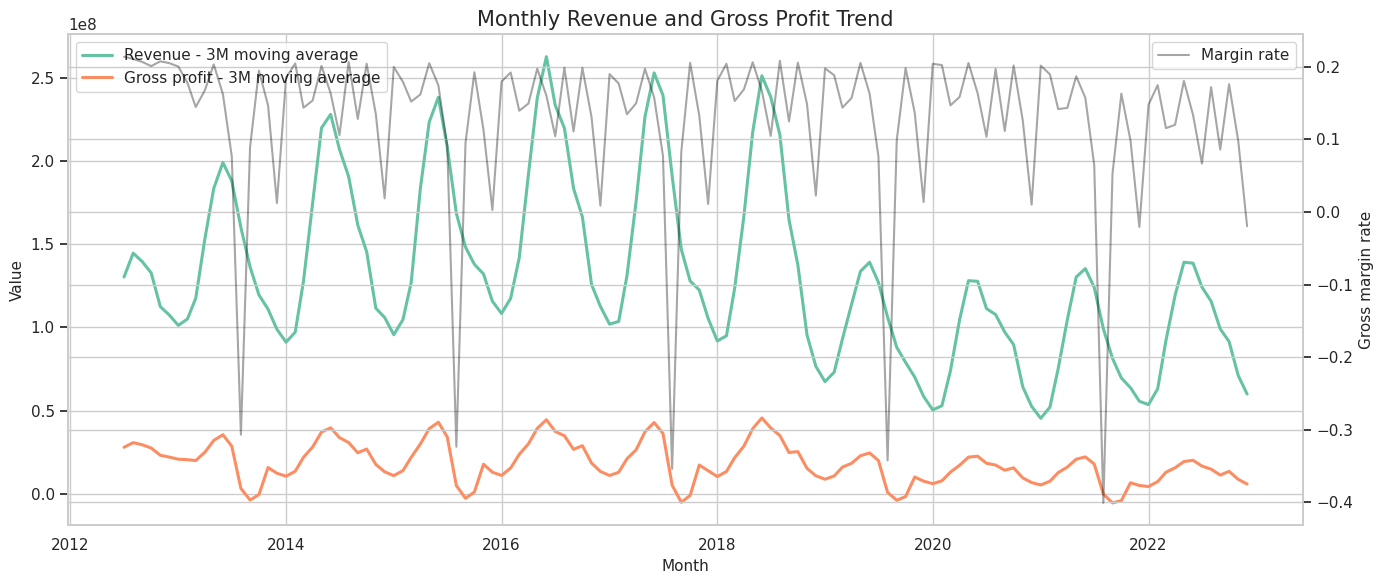


**Findings**

- Tổng doanh thu năm đầu (2012) là **741,497,748**, năm cuối (2022) là **1,169,748,832**, tương đương thay đổi **57.8%**.
- Tháng có doanh thu cao nhất là **2018-06** với doanh thu **271,674,172**.
- Tháng có margin thấp nhất là **2021-08**, margin chỉ **-40.09%**.
- Năm doanh thu lớn nhất là **2016** với doanh thu **2,104,640,678**.

**Business interpretation**

Doanh nghiệp không nên chỉ tối ưu doanh thu. Các tháng doanh thu cao nhưng margin thấp cần được kiểm tra theo khuyến mãi, COGS và return để tránh tăng GMV nhưng giảm lợi nhuận. Với các tháng peak lặp lại theo mùa, đội vận hành nên chuẩn bị tồn kho và logistics trước 4-8 tuần.


In [18]:
sales2 = sales.copy()
sales2['gross_profit'] = sales2['Revenue'] - sales2['COGS']
sales2['margin_rate'] = safe_divide(sales2['gross_profit'], sales2['Revenue'])
sales2['year_month'] = sales2['Date'].dt.to_period('M').dt.to_timestamp()
sales2['year'] = sales2['Date'].dt.year
sales2['month'] = sales2['Date'].dt.month

monthly_sales = sales2.groupby('year_month', as_index=False).agg(
    revenue=('Revenue', 'sum'),
    cogs=('COGS', 'sum'),
    gross_profit=('gross_profit', 'sum')
)
monthly_sales['margin_rate'] = safe_divide(monthly_sales['gross_profit'], monthly_sales['revenue'])
monthly_sales['revenue_ma3'] = monthly_sales['revenue'].rolling(3, min_periods=1).mean()
monthly_sales['profit_ma3'] = monthly_sales['gross_profit'].rolling(3, min_periods=1).mean()

yearly_sales = sales2.groupby('year', as_index=False).agg(
    revenue=('Revenue', 'sum'),
    gross_profit=('gross_profit', 'sum')
)
yearly_sales['margin_rate'] = safe_divide(yearly_sales['gross_profit'], yearly_sales['revenue'])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(monthly_sales['year_month'], monthly_sales['revenue_ma3'], label='Revenue - 3M moving average', linewidth=2.2)
ax1.plot(monthly_sales['year_month'], monthly_sales['profit_ma3'], label='Gross profit - 3M moving average', linewidth=2.2)
ax1.set_title('Monthly Revenue and Gross Profit Trend')
ax1.set_xlabel('Month')
ax1.set_ylabel('Value')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(monthly_sales['year_month'], monthly_sales['margin_rate'], color='black', alpha=0.35, label='Margin rate')
ax2.set_ylabel('Gross margin rate')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_revenue_margin_trend.png', dpi=180, bbox_inches='tight')
plt.show()

peak_month = monthly_sales.loc[monthly_sales['revenue'].idxmax()]
low_margin_month = monthly_sales.loc[monthly_sales['margin_rate'].idxmin()]
best_year = yearly_sales.loc[yearly_sales['revenue'].idxmax()]
first_year = yearly_sales.iloc[0]
last_year = yearly_sales.iloc[-1]
revenue_growth = (last_year['revenue'] / first_year['revenue'] - 1) * 100

msg = f'''
**Key findings**

- Tổng doanh thu năm đầu ({int(first_year['year'])}) là **{first_year['revenue']:,.0f}**, năm cuối ({int(last_year['year'])}) là **{last_year['revenue']:,.0f}**, tương đương thay đổi **{revenue_growth:,.1f}%**.
- Tháng có doanh thu cao nhất là **{peak_month['year_month'].strftime('%Y-%m')}** với doanh thu **{peak_month['revenue']:,.0f}**.
- Tháng có margin thấp nhất là **{low_margin_month['year_month'].strftime('%Y-%m')}**, margin chỉ **{low_margin_month['margin_rate']:.2%}**.
- Năm doanh thu lớn nhất là **{int(best_year['year'])}** với doanh thu **{best_year['revenue']:,.0f}**.

**Business implication / action**

Các tháng doanh thu cao không tự động đồng nghĩa với hiệu quả tốt nếu margin bị kéo xuống. Nhóm tháng có revenue cao nhưng margin thấp cần được kiểm tra thêm theo khuyến mãi, COGS và return. Với các tháng peak có tính lặp lại, tồn kho và logistics nên được chuẩn bị sớm hơn khoảng 4-8 tuần.
'''
display(Markdown(msg))

## Insight 2 - Product portfolio performance

**Rubric focus:** Descriptive + Diagnostic + Prescriptive.  
Câu hỏi kinh doanh: **nhóm sản phẩm nào vừa tạo doanh thu, vừa có margin tốt, vừa ít rủi ro trả hàng?**

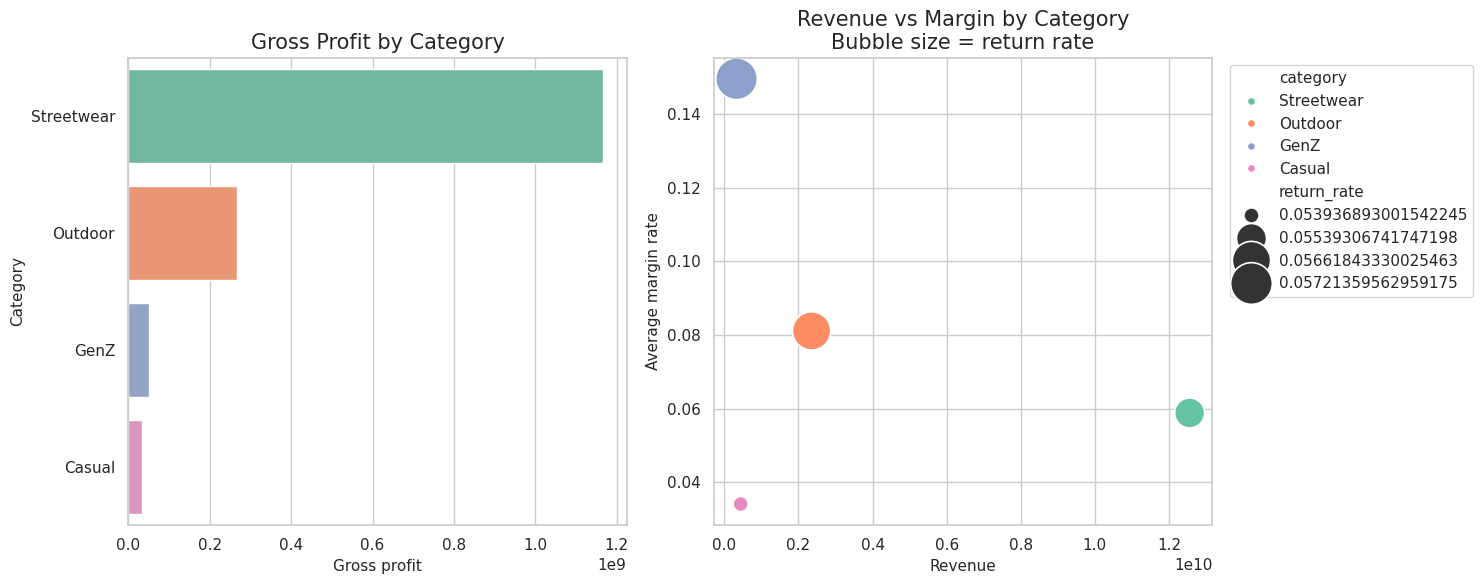

,category,revenue,gross_profit,units,orders,avg_margin,return_rate,avg_discount_rate,profit_share,revenue_share
3,Streetwear,"12,558,477,099.17","1,165,807,511.55",1768826,389543,0.06,0.06,0.05,0.77,0.80
2,Outdoor,"2,353,396,796.86","267,034,092.02",1170000,200454,0.08,0.06,0.07,0.18,0.15
1,GenZ,"328,710,175.65","50,836,377.50",166848,37054,0.15,0.06,0.05,0.03,0.02
0,Casual,"440,285,193.75","33,740,765.23",107469,23600,0.03,0.05,0.05,0.02,0.03



**Findings**

- Category đóng góp gross profit cao nhất là **Streetwear**, với gross profit **1,165,807,512**, chiếm **76.8%** tổng gross profit.
- Category có margin trung bình cao nhất là **GenZ**, margin **14.95%**.
- Category có return rate cao nhất là **GenZ**, return flag rate **5.72%**.

**Business interpretation**

Ưu tiên tăng trưởng không nên dựa vào revenue đơn thuần. Nhóm có gross profit cao và return rate thấp nên được ưu tiên ngân sách marketing. Nhóm có doanh thu lớn nhưng return rate hoặc discount rate cao cần được kiểm tra lại sizing, mô tả sản phẩm, chính sách khuyến mãi và chất lượng fulfillment.


In [19]:
cat_perf = df.groupby('category', as_index=False).agg(
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    units=('quantity', 'sum'),
    orders=('order_id', 'nunique'),
    avg_margin=('gross_margin_rate', 'mean'),
    return_rate=('return_flag', 'mean'),
    avg_discount_rate=('discount_rate', 'mean')
)
cat_perf['profit_share'] = safe_divide(cat_perf['gross_profit'], cat_perf['gross_profit'].sum())
cat_perf['revenue_share'] = safe_divide(cat_perf['revenue'], cat_perf['revenue'].sum())
cat_perf = cat_perf.sort_values('gross_profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=cat_perf, y='category', x='gross_profit', ax=axes[0], palette='Set2')
axes[0].set_title('Gross Profit by Category')
axes[0].set_xlabel('Gross profit')
axes[0].set_ylabel('Category')

sns.scatterplot(data=cat_perf, x='revenue', y='avg_margin', size='return_rate', hue='category', sizes=(120, 900), ax=axes[1])
axes[1].set_title('Revenue vs Margin by Category\nBubble size = return rate')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Average margin rate')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_category_portfolio.png', dpi=180, bbox_inches='tight')
plt.show()

display(cat_perf)

top_profit_cat = cat_perf.iloc[0]
top_margin_cat = cat_perf.loc[cat_perf['avg_margin'].idxmax()]
top_return_cat = cat_perf.loc[cat_perf['return_rate'].idxmax()]

msg = f'''
**Key findings**

- Category đóng góp gross profit cao nhất là **{top_profit_cat['category']}**, với gross profit **{top_profit_cat['gross_profit']:,.0f}**, chiếm **{top_profit_cat['profit_share']:.1%}** tổng gross profit.
- Category có margin trung bình cao nhất là **{top_margin_cat['category']}**, margin **{top_margin_cat['avg_margin']:.2%}**.
- Category có return rate cao nhất là **{top_return_cat['category']}**, return flag rate **{top_return_cat['return_rate']:.2%}**.

**Business implication / action**

Nếu chỉ nhìn revenue, một số nhóm sản phẩm có thể trông hấp dẫn hơn thực tế. Nhóm có gross profit cao và return rate thấp phù hợp để ưu tiên marketing. Ngược lại, nhóm doanh thu lớn nhưng return rate hoặc discount rate cao cần được rà soát về sizing, mô tả sản phẩm, chính sách khuyến mãi và fulfillment.
'''
display(Markdown(msg))

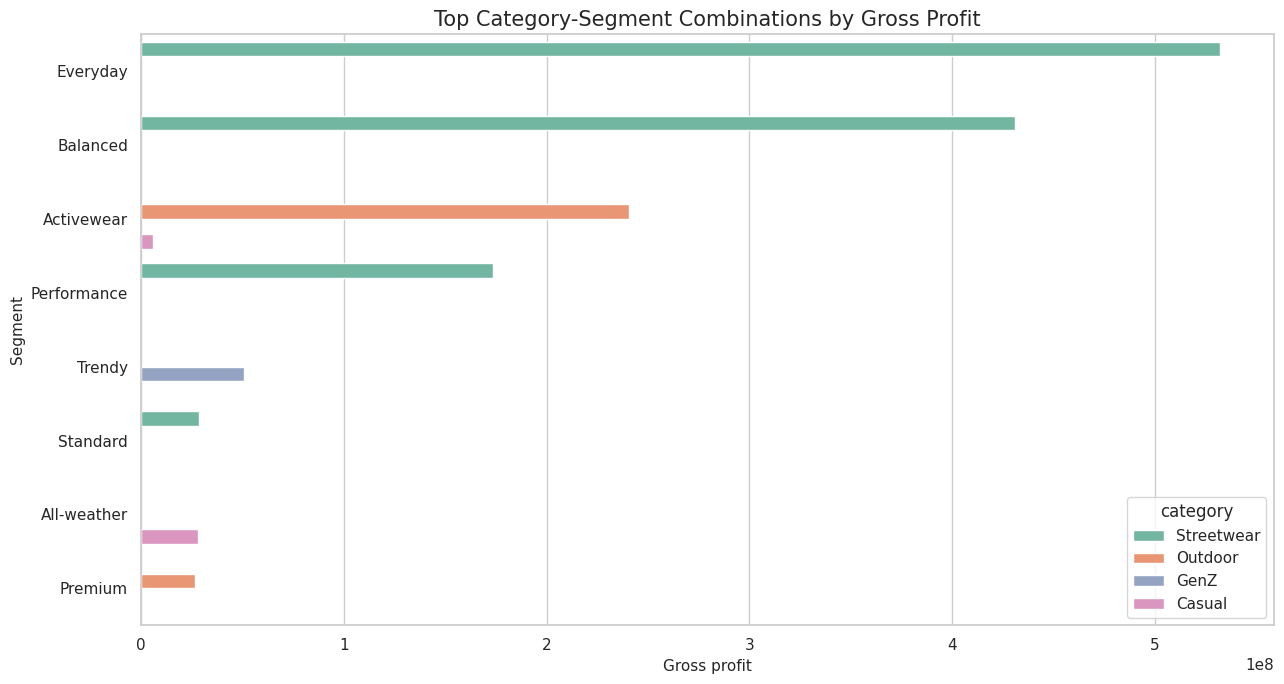

,category,segment,revenue,gross_profit,units,avg_margin,return_rate
6,Streetwear,Everyday,"5,147,454,916.61","532,174,759.32",819449,0.07,0.06
5,Streetwear,Balanced,"4,900,317,965.89","431,236,060.66",464217,0.06,0.05
3,Outdoor,Activewear,"1,899,184,896.32","240,447,865.89",1030535,0.09,0.06
7,Streetwear,Performance,"2,285,029,332.18","173,693,836.66",435685,0.04,0.06
2,GenZ,Trendy,"328,710,175.65","50,836,377.50",166848,0.15,0.06
8,Streetwear,Standard,"225,674,884.49","28,702,854.91",49475,0.09,0.05
1,Casual,All-weather,"408,765,115.41","27,849,081.93",101147,0.03,0.05
4,Outdoor,Premium,"454,211,900.54","26,586,226.14",139465,0.03,0.06
0,Casual,Activewear,"31,520,078.34","5,891,683.30",6322,0.17,0.06


In [20]:
seg_perf = df.groupby(['category', 'segment'], as_index=False).agg(
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    units=('quantity', 'sum'),
    avg_margin=('gross_margin_rate', 'mean'),
    return_rate=('return_flag', 'mean')
)
seg_perf = seg_perf.sort_values('gross_profit', ascending=False).head(15)

plt.figure(figsize=(13, 7))
sns.barplot(data=seg_perf, y='segment', x='gross_profit', hue='category')
plt.title('Top Category-Segment Combinations by Gross Profit')
plt.xlabel('Gross profit')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_top_segments_profit.png', dpi=180, bbox_inches='tight')
plt.show()

display(seg_perf)

## Insight 3 - Promotion effectiveness

**Rubric focus:** Diagnostic + Prescriptive.  
Câu hỏi kinh doanh: **khuyến mãi đang tạo tăng trưởng thật hay chỉ đang mua doanh thu bằng cách hy sinh margin?**

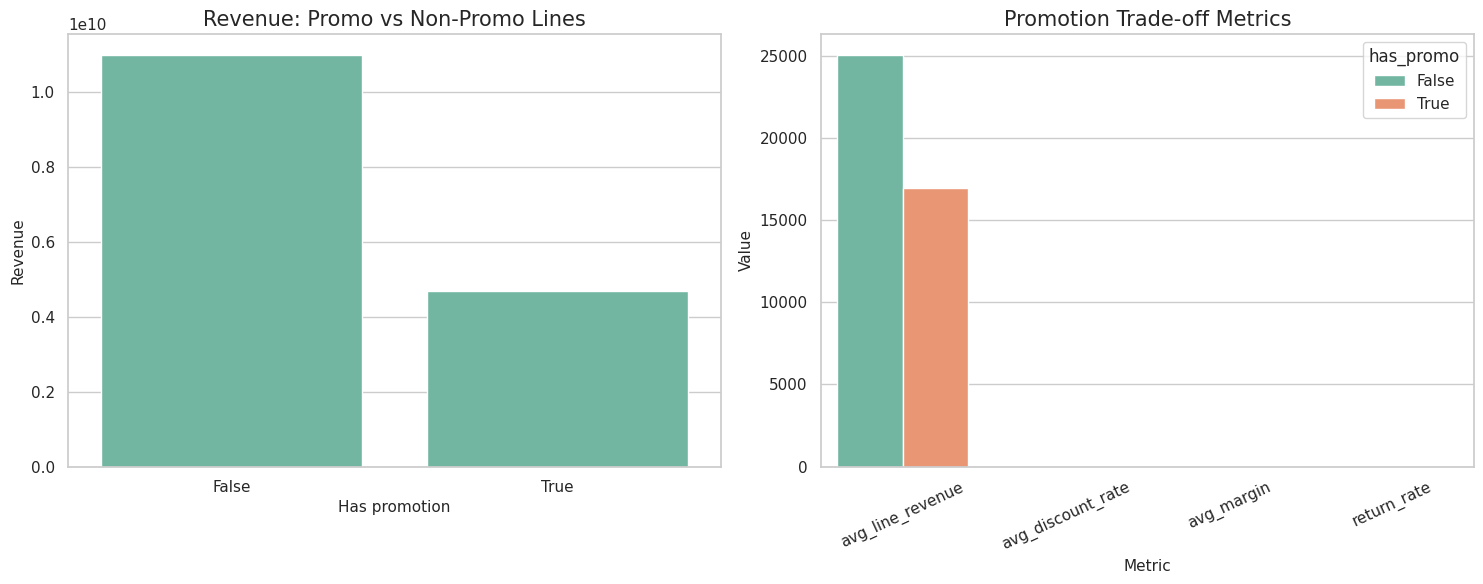

,has_promo,rows,orders,revenue,gross_profit,avg_line_revenue,avg_discount_rate,avg_margin,return_rate,revenue_share
0,False,438353,398972,"10,995,039,052.90","2,195,015,385.58","25,082.61",0.00,0.21,0.06,0.70
1,True,276316,248242,"4,685,830,212.53","-677,596,639.27","16,958.23",0.14,-0.15,0.06,0.30



**Findings**

- Các dòng có promo chiếm **38.7%** số dòng order item và **29.9%** doanh thu.
- Average discount rate của dòng có promo là **14.30%**, so với **0.00%** ở dòng không promo.
- Margin của promo thấp/cao hơn non-promo **-35.56%** điểm; return rate chênh lệch **-0.00%** điểm.

**Business interpretation**

Promo chỉ nên được scale nếu incremental revenue bù được phần margin bị giảm và không làm tăng return. Cần ưu tiên promo có điều kiện theo category, min order value và nhóm khách hàng thay vì discount đại trà.


In [21]:
promo_perf = df.groupby('has_promo', as_index=False).agg(
    rows=('order_id', 'count'),
    orders=('order_id', 'nunique'),
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    avg_line_revenue=('net_revenue', 'mean'),
    avg_discount_rate=('discount_rate', 'mean'),
    avg_margin=('gross_margin_rate', 'mean'),
    return_rate=('return_flag', 'mean')
)
promo_perf['revenue_share'] = safe_divide(promo_perf['revenue'], promo_perf['revenue'].sum())

plot_df = promo_perf.melt(
    id_vars='has_promo',
    value_vars=['avg_line_revenue', 'avg_discount_rate', 'avg_margin', 'return_rate'],
    var_name='metric',
    value_name='value'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=promo_perf, x='has_promo', y='revenue', ax=axes[0])
axes[0].set_title('Revenue: Promo vs Non-Promo Lines')
axes[0].set_xlabel('Has promotion')
axes[0].set_ylabel('Revenue')

sns.barplot(data=plot_df, x='metric', y='value', hue='has_promo', ax=axes[1])
axes[1].set_title('Promotion Trade-off Metrics')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_promotion_tradeoff.png', dpi=180, bbox_inches='tight')
plt.show()

display(promo_perf)

promo_yes = promo_perf[promo_perf['has_promo'] == True].iloc[0]
promo_no = promo_perf[promo_perf['has_promo'] == False].iloc[0]
margin_gap = promo_yes['avg_margin'] - promo_no['avg_margin']
return_gap = promo_yes['return_rate'] - promo_no['return_rate']

msg = f'''
**Key findings**

- Các dòng có promo chiếm **{promo_yes['rows'] / promo_perf['rows'].sum():.1%}** số dòng order item và **{promo_yes['revenue_share']:.1%}** doanh thu.
- Average discount rate của dòng có promo là **{promo_yes['avg_discount_rate']:.2%}**, so với **{promo_no['avg_discount_rate']:.2%}** ở dòng không promo.
- Chênh lệch margin giữa promo và non-promo là **{margin_gap:.2%}** điểm; return rate chênh lệch **{return_gap:.2%}** điểm.

**Business implication / action**

Promo nên được đánh giá bằng cả revenue, margin và return, không chỉ bằng doanh số. Các chiến dịch có điều kiện theo category, min order value hoặc nhóm khách hàng có khả năng kiểm soát margin tốt hơn discount đại trà.
'''
display(Markdown(msg))

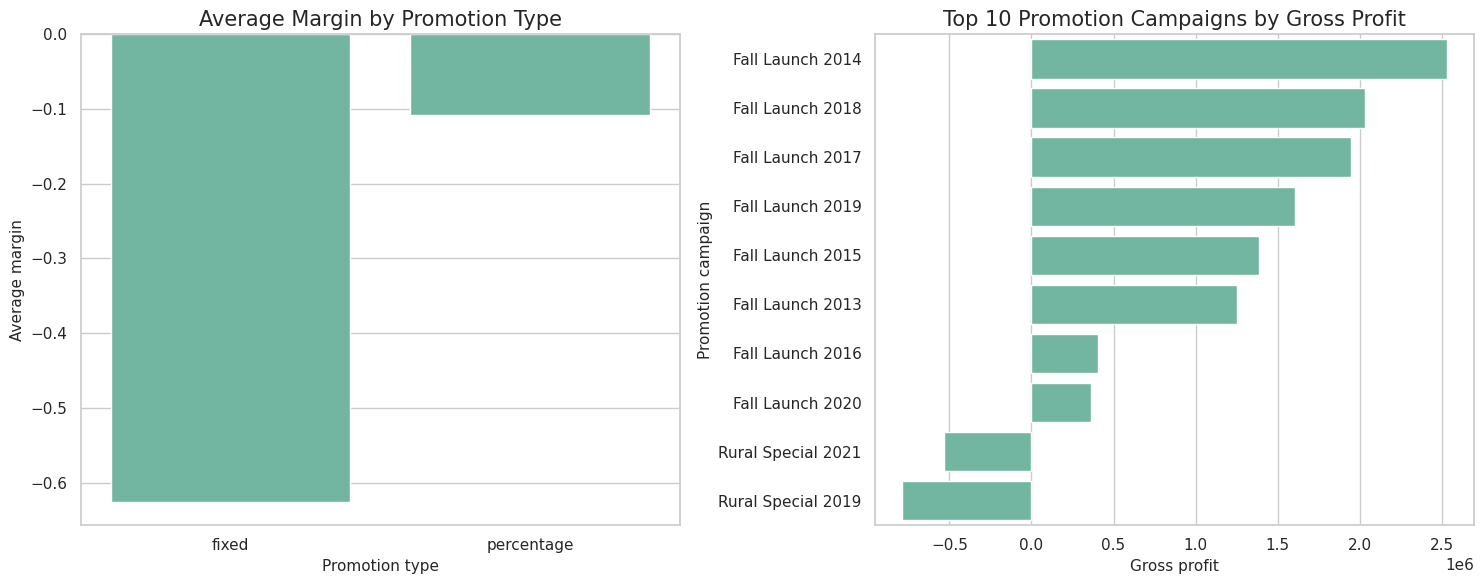

,promo_type,rows,revenue,gross_profit,avg_discount_rate,avg_margin,return_rate
0,fixed,20950,"371,747,191.30","-235,257,291.33",0.02,-0.63,0.06
1,percentage,255366,"4,314,083,021.23","-442,339,347.94",0.15,-0.11,0.06


,promo_name,revenue,gross_profit,avg_discount_rate,avg_margin,return_rate,rows
1,Fall Launch 2014,"102,386,562.04","2,530,603.38",0.10,0.02,0.06,5637
5,Fall Launch 2018,"103,549,647.81","2,031,416.62",0.10,0.03,0.06,4328
4,Fall Launch 2017,"116,135,214.62","1,944,308.36",0.10,0.03,0.06,5413
6,Fall Launch 2019,"72,746,607.20","1,603,420.32",0.10,0.03,0.06,3101
2,Fall Launch 2015,"137,516,810.07","1,385,017.87",0.10,0.03,0.06,7498
0,Fall Launch 2013,"117,265,398.84","1,252,606.74",0.10,0.02,0.06,6277
3,Fall Launch 2016,"122,066,567.29","403,896.24",0.10,0.02,0.05,5763
7,Fall Launch 2020,"68,214,466.80","361,014.87",0.10,0.02,0.06,2593
24,Rural Special 2021,"6,213,990.53","-534,770.73",0.15,-0.08,0.06,588
23,Rural Special 2019,"9,916,436.30","-787,821.80",0.15,-0.07,0.05,1082


In [22]:
promo_detail = df.merge(
    promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'applicable_category', 'promo_channel', 'min_order_value']],
    on='promo_id', how='left'
)

promo_type_perf = promo_detail[promo_detail['has_promo']].groupby('promo_type', as_index=False).agg(
    rows=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    avg_discount_rate=('discount_rate', 'mean'),
    avg_margin=('gross_margin_rate', 'mean'),
    return_rate=('return_flag', 'mean')
).sort_values('gross_profit', ascending=False)

campaign_perf = promo_detail[promo_detail['has_promo']].groupby('promo_name', as_index=False).agg(
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    avg_discount_rate=('discount_rate', 'mean'),
    avg_margin=('gross_margin_rate', 'mean'),
    return_rate=('return_flag', 'mean'),
    rows=('order_id', 'count')
).sort_values('gross_profit', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=promo_type_perf, x='promo_type', y='avg_margin', ax=axes[0])
axes[0].set_title('Average Margin by Promotion Type')
axes[0].set_xlabel('Promotion type')
axes[0].set_ylabel('Average margin')

sns.barplot(data=campaign_perf, y='promo_name', x='gross_profit', ax=axes[1])
axes[1].set_title('Top 10 Promotion Campaigns by Gross Profit')
axes[1].set_xlabel('Gross profit')
axes[1].set_ylabel('Promotion campaign')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_promotion_campaigns.png', dpi=180, bbox_inches='tight')
plt.show()

display(promo_type_perf)
display(campaign_perf)

## Insight 4 - Returns, delivery, and customer satisfaction

**Rubric focus:** Diagnostic + Prescriptive.  
Câu hỏi kinh doanh: **doanh nghiệp đang mất lợi nhuận ở đâu sau bán hàng, và nguyên nhân có liên quan tới sản phẩm hay logistics không?**

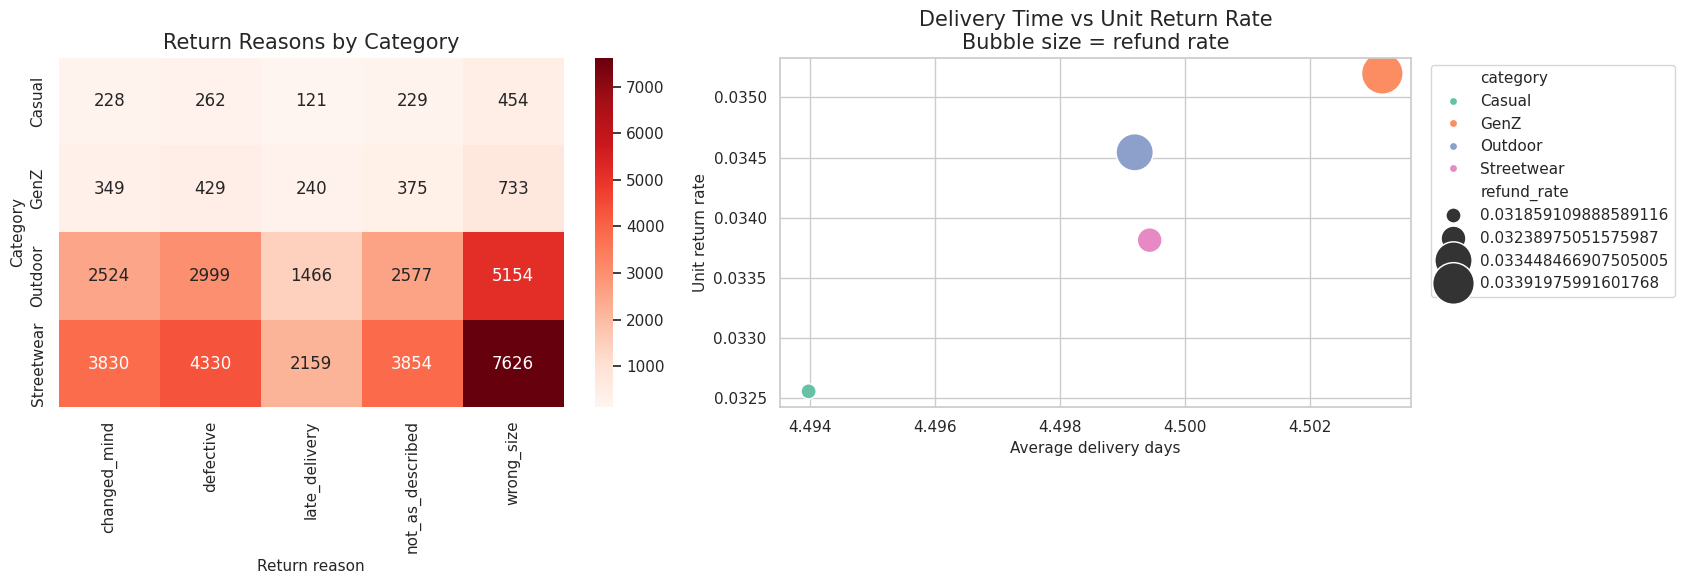

,category,units_sold,units_returned,refund_amount,revenue,avg_delivery_days,avg_rating,unit_return_rate,refund_rate
1,GenZ,166848,"5,873.00","11,149,770.24","328,710,175.65",4.50,3.92,0.04,0.03
2,Outdoor,1170000,"40,417.00","78,717,514.88","2,353,396,796.86",4.50,3.93,0.03,0.03
3,Streetwear,1768826,"59,812.00","406,765,940.10","12,558,477,099.17",4.50,3.94,0.03,0.03
0,Casual,107469,"3,499.00","14,027,094.37","440,285,193.75",4.49,3.92,0.03,0.03



**Findings**

- Lý do trả hàng phổ biến nhất toàn bộ dữ liệu là **wrong_size** với **13,967** bản ghi.
- Category có unit return rate cao nhất là **GenZ**, return rate **3.52%**.
- Category có refund rate cao nhất là **GenZ**, refund/revenue **3.39%**.

**Business interpretation**

Nếu lý do trả hàng tập trung vào `wrong_size`, nên cải thiện size guide, ảnh fit thật và review theo vóc dáng. Nếu tập trung vào `late_delivery`, cần tối ưu carrier/vùng giao hàng. Nếu tập trung vào `defective`, cần kiểm tra supplier hoặc quy trình QC. Đây là nhóm insight có tính hành động cao vì mỗi nguyên nhân dẫn tới một can thiệp vận hành khác nhau.


In [23]:
return_reason = returns.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id', how='left')
reason_pivot = return_reason.pivot_table(
    index='category',
    columns='return_reason',
    values='return_id',
    aggfunc='count',
    fill_value=0
)

return_cat = df.groupby('category', as_index=False).agg(
    units_sold=('quantity', 'sum'),
    units_returned=('returned_qty', 'sum'),
    refund_amount=('refund_amount', 'sum'),
    revenue=('net_revenue', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_rating=('avg_rating', 'mean')
)
return_cat['unit_return_rate'] = safe_divide(return_cat['units_returned'], return_cat['units_sold'])
return_cat['refund_rate'] = safe_divide(return_cat['refund_amount'], return_cat['revenue'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(reason_pivot, annot=True, fmt='.0f', cmap='Reds', ax=axes[0])
axes[0].set_title('Return Reasons by Category')
axes[0].set_xlabel('Return reason')
axes[0].set_ylabel('Category')

sns.scatterplot(data=return_cat, x='avg_delivery_days', y='unit_return_rate', size='refund_rate', hue='category', sizes=(120, 900), ax=axes[1])
axes[1].set_title('Delivery Time vs Unit Return Rate\nBubble size = refund rate')
axes[1].set_xlabel('Average delivery days')
axes[1].set_ylabel('Unit return rate')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_returns_delivery.png', dpi=180, bbox_inches='tight')
plt.show()

display(return_cat.sort_values('unit_return_rate', ascending=False))

top_reason = returns['return_reason'].value_counts().idxmax()
top_reason_count = returns['return_reason'].value_counts().max()
top_return_cat2 = return_cat.loc[return_cat['unit_return_rate'].idxmax()]
worst_refund_cat = return_cat.loc[return_cat['refund_rate'].idxmax()]

msg = f'''
**Key findings**

- Lý do trả hàng phổ biến nhất toàn bộ dữ liệu là **{top_reason}** với **{top_reason_count:,.0f}** bản ghi.
- Category có unit return rate cao nhất là **{top_return_cat2['category']}**, return rate **{top_return_cat2['unit_return_rate']:.2%}**.
- Category có refund rate cao nhất là **{worst_refund_cat['category']}**, refund/revenue **{worst_refund_cat['refund_rate']:.2%}**.

**Business implication / action**

Mỗi nhóm lý do trả hàng dẫn tới một hướng xử lý khác nhau: `wrong_size` gợi ý cải thiện size guide và ảnh fit thật; `late_delivery` gợi ý kiểm tra carrier hoặc vùng giao hàng; `defective` gợi ý rà soát supplier và quy trình QC.
'''
display(Markdown(msg))

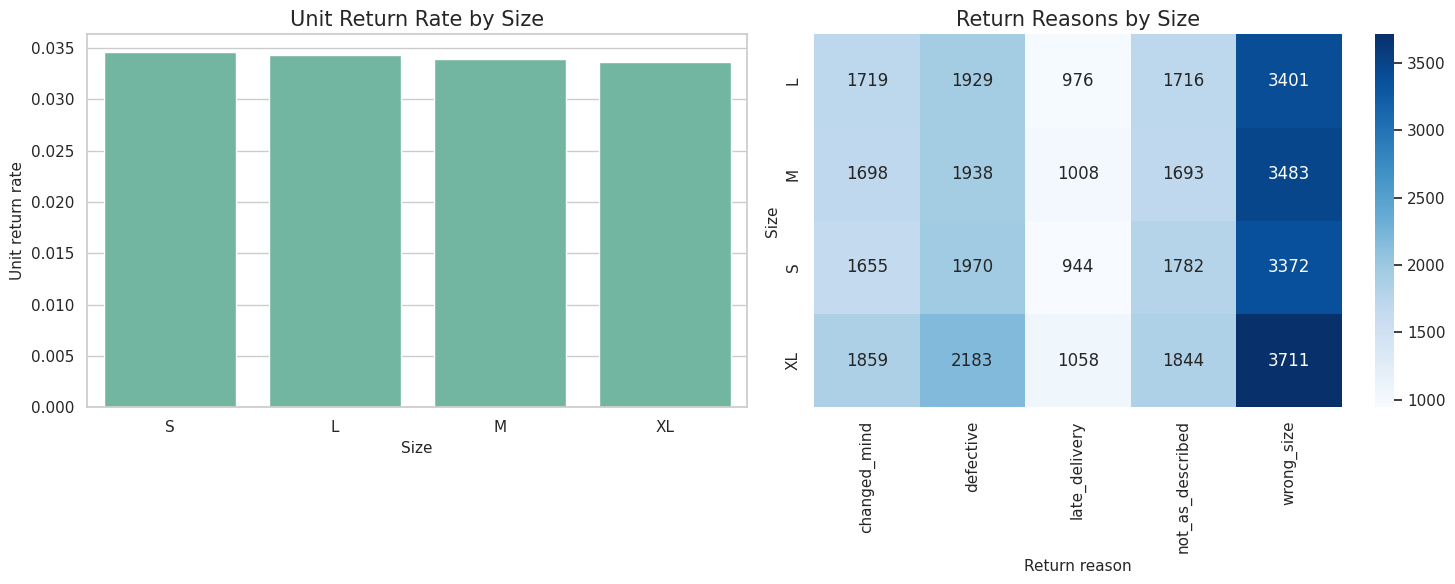

,size,units_sold,units_returned,unit_return_rate
2,S,774468,26797,0.03
0,L,778599,26688,0.03
1,M,792889,26932,0.03
3,XL,867187,29169,0.03


In [24]:
size_return = return_reason.groupby(['size', 'return_reason'], as_index=False).agg(
    returns=('return_id', 'count'),
    refund=('refund_amount', 'sum')
)
size_sold = df.groupby('size', as_index=False).agg(units_sold=('quantity', 'sum'))
size_return_total = return_reason.groupby('size', as_index=False).agg(units_returned=('return_quantity', 'sum'))
size_summary = size_sold.merge(size_return_total, on='size', how='left').fillna(0)
size_summary['unit_return_rate'] = safe_divide(size_summary['units_returned'], size_summary['units_sold'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=size_summary.sort_values('unit_return_rate', ascending=False), x='size', y='unit_return_rate', ax=axes[0])
axes[0].set_title('Unit Return Rate by Size')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Unit return rate')

size_reason_pivot = size_return.pivot_table(index='size', columns='return_reason', values='returns', aggfunc='sum', fill_value=0)
sns.heatmap(size_reason_pivot, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Return Reasons by Size')
axes[1].set_xlabel('Return reason')
axes[1].set_ylabel('Size')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_size_return_risk.png', dpi=180, bbox_inches='tight')
plt.show()

display(size_summary.sort_values('unit_return_rate', ascending=False))

## Insight 5 - Web traffic quality and conversion proxy

**Rubric focus:** Diagnostic + Predictive.  
Câu hỏi kinh doanh: **nguồn traffic nào tạo engagement tốt, và traffic có chuyển thành đơn hàng không?**

Dữ liệu không có session-level conversion, vì vậy notebook dùng proxy `daily_orders / sessions` để ước lượng conversion potential ở cấp ngày.

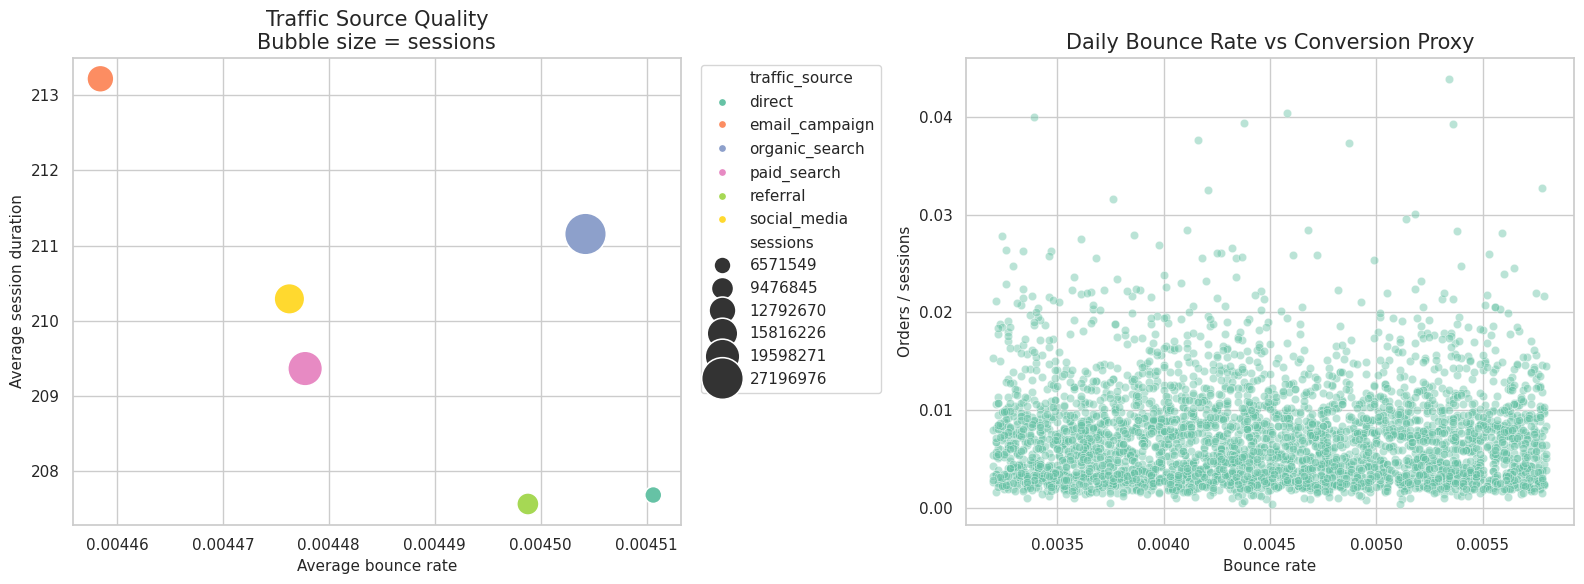

,traffic_source,days,sessions,avg_bounce,avg_duration,page_views,views_per_session
1,email_campaign,505,12792670,0.00,213.22,55477636,4.34
5,social_media,632,15816226,0.00,210.29,68072140,4.30
3,paid_search,784,19598271,0.00,209.36,85079551,4.34
4,referral,375,9476845,0.00,207.56,41655659,4.40
2,organic_search,1090,27196976,0.00,211.15,117606452,4.32
0,direct,266,6571549,0.00,207.68,28771362,4.38



**Findings**

- Traffic source có bounce rate thấp nhất là **email_campaign**, average bounce **0.45%**.
- Traffic source có session duration cao nhất là **email_campaign**, average duration **213.2 giây**.
- Tương quan giữa daily bounce rate và conversion proxy là **-0.028**.

**Business interpretation**

Nguồn traffic có session duration cao và bounce thấp nên được ưu tiên scale hoặc học lại creative/landing page. Nguồn có nhiều sessions nhưng bounce cao cần audit thông điệp quảng cáo, landing page và đối tượng target trước khi tăng ngân sách.


In [25]:
daily_orders = orders.groupby('order_date', as_index=False).agg(
    orders=('order_id', 'nunique')
)

traffic_daily = web.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
)
traffic_orders = traffic_daily.merge(daily_orders, left_on='date', right_on='order_date', how='left')
traffic_orders['orders'] = traffic_orders['orders'].fillna(0)
traffic_orders['conversion_proxy'] = safe_divide(traffic_orders['orders'], traffic_orders['sessions'])
traffic_orders['month'] = traffic_orders['date'].dt.to_period('M').dt.to_timestamp()

source_perf = web.groupby('traffic_source', as_index=False).agg(
    days=('date', 'count'),
    sessions=('sessions', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean'),
    page_views=('page_views', 'sum')
)
source_perf['views_per_session'] = safe_divide(source_perf['page_views'], source_perf['sessions'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=source_perf, x='avg_bounce', y='avg_duration', size='sessions', hue='traffic_source', sizes=(150, 900), ax=axes[0])
axes[0].set_title('Traffic Source Quality\nBubble size = sessions')
axes[0].set_xlabel('Average bounce rate')
axes[0].set_ylabel('Average session duration')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(data=traffic_orders, x='bounce_rate', y='conversion_proxy', alpha=0.45, ax=axes[1])
axes[1].set_title('Daily Bounce Rate vs Conversion Proxy')
axes[1].set_xlabel('Bounce rate')
axes[1].set_ylabel('Orders / sessions')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_traffic_quality.png', dpi=180, bbox_inches='tight')
plt.show()

display(source_perf.sort_values('avg_bounce'))

best_source = source_perf.loc[source_perf['avg_bounce'].idxmin()]
long_source = source_perf.loc[source_perf['avg_duration'].idxmax()]
corr = traffic_orders[['bounce_rate', 'conversion_proxy']].corr().iloc[0, 1]

msg = f'''
**Key findings**

- Traffic source có bounce rate thấp nhất là **{best_source['traffic_source']}**, average bounce **{best_source['avg_bounce']:.2%}**.
- Traffic source có session duration cao nhất là **{long_source['traffic_source']}**, average duration **{long_source['avg_duration']:,.1f} giây**.
- Tương quan giữa daily bounce rate và conversion proxy là **{corr:.3f}**.

**Business implication / action**

Nguồn traffic có session duration cao và bounce thấp là nhóm đáng xem xét tăng ngân sách. Với nguồn có nhiều sessions nhưng bounce cao, cần kiểm tra lại thông điệp quảng cáo, landing page và tệp target trước khi mở rộng.
'''
display(Markdown(msg))

## Insight 6 - Inventory risk: stockout vs overstock

**Rubric focus:** Diagnostic + Prescriptive.  
Câu hỏi kinh doanh: **hàng bán tốt có bị thiếu không, và vốn có đang bị kẹt ở hàng chậm không?**

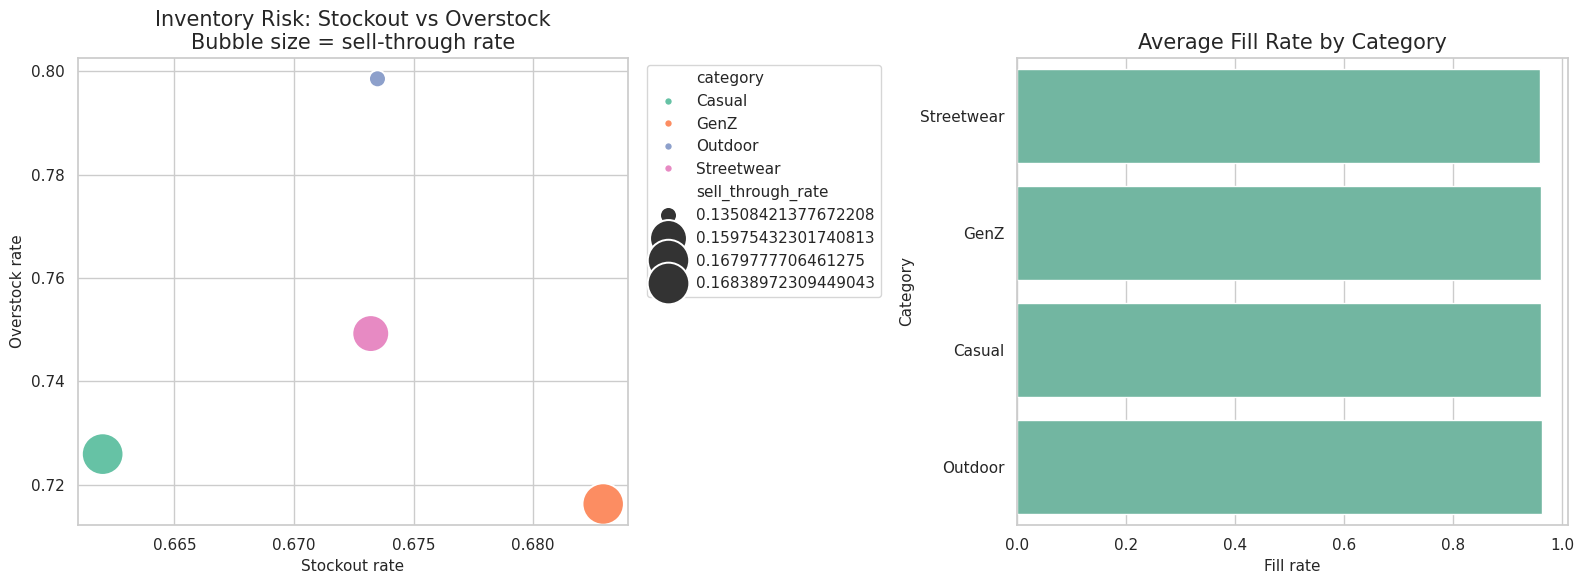

,category,stock_on_hand,units_received,units_sold,stockout_days,avg_days_supply,fill_rate,stockout_rate,overstock_rate,reorder_rate,sell_through_rate
1,GenZ,584757,56311,48695,5368,718.81,0.96,0.68,0.72,0.00,0.17
2,Outdoor,4749891,395568,337510,23552,"1,068.84",0.96,0.67,0.80,0.00,0.14
3,Streetwear,5759494,599599,511467,36993,887.14,0.96,0.67,0.75,0.00,0.16
0,Casual,310522,35788,31202,4012,459.13,0.96,0.66,0.73,0.00,0.17



**Findings**

- Category có stockout rate cao nhất là **GenZ**, stockout rate **68.29%**.
- Category có overstock rate cao nhất là **Outdoor**, overstock rate **79.85%**.
- Category có fill rate thấp nhất là **Streetwear**, fill rate **96.02%**.

**Business interpretation**

Stockout cao ở nhóm bán tốt có thể làm mất doanh thu và làm giảm trải nghiệm khách hàng. Overstock cao ở nhóm sell-through thấp làm kẹt vốn. Cần tách chính sách tồn kho: tăng reorder threshold cho nhóm stockout cao + sell-through cao, và chạy markdown/clearance hoặc giảm nhập cho nhóm overstock cao + sell-through thấp.


In [26]:
inv_summary = inventory.groupby('category', as_index=False).agg(
    stock_on_hand=('stock_on_hand', 'sum'),
    units_received=('units_received', 'sum'),
    units_sold=('units_sold', 'sum'),
    stockout_days=('stockout_days', 'sum'),
    avg_days_supply=('days_of_supply', 'mean'),
    fill_rate=('fill_rate', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    reorder_rate=('reorder_flag', 'mean'),
    sell_through_rate=('sell_through_rate', 'mean')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=inv_summary, x='stockout_rate', y='overstock_rate', size='sell_through_rate', hue='category', sizes=(150, 900), ax=axes[0])
axes[0].set_title('Inventory Risk: Stockout vs Overstock\nBubble size = sell-through rate')
axes[0].set_xlabel('Stockout rate')
axes[0].set_ylabel('Overstock rate')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=inv_summary.sort_values('fill_rate'), y='category', x='fill_rate', ax=axes[1])
axes[1].set_title('Average Fill Rate by Category')
axes[1].set_xlabel('Fill rate')
axes[1].set_ylabel('Category')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_inventory_risk.png', dpi=180, bbox_inches='tight')
plt.show()

display(inv_summary.sort_values('stockout_rate', ascending=False))

stockout_cat = inv_summary.loc[inv_summary['stockout_rate'].idxmax()]
overstock_cat = inv_summary.loc[inv_summary['overstock_rate'].idxmax()]
low_fill_cat = inv_summary.loc[inv_summary['fill_rate'].idxmin()]

msg = f'''
**Key findings**

- Category có stockout rate cao nhất là **{stockout_cat['category']}**, stockout rate **{stockout_cat['stockout_rate']:.2%}**.
- Category có overstock rate cao nhất là **{overstock_cat['category']}**, overstock rate **{overstock_cat['overstock_rate']:.2%}**.
- Category có fill rate thấp nhất là **{low_fill_cat['category']}**, fill rate **{low_fill_cat['fill_rate']:.2%}**.

**Business implication / action**

Stockout cao ở nhóm bán tốt có thể làm mất doanh thu, trong khi overstock ở nhóm sell-through thấp làm kẹt vốn. Chính sách tồn kho nên tách theo rủi ro: tăng reorder threshold cho nhóm stockout cao + sell-through cao, và giảm nhập hoặc clearance cho nhóm overstock cao + sell-through thấp.
'''
display(Markdown(msg))

## Action Summary

Bảng dưới đây tổng hợp các tín hiệu chính từ EDA thành đề xuất hành động. Đây là phần Prescriptive, tương ứng với yêu cầu của đề về business implications và actionable recommendations.

In [27]:
recommendations = pd.DataFrame([
    {'rubric_level': 'Predictive / Prescriptive', 'area': 'Revenue planning', 'signal': 'Doanh thu và margin biến động theo tháng', 'action': 'Dự báo nhu cầu theo mùa; chuẩn bị inventory và logistics trước tháng peak; kiểm tra các tháng revenue cao nhưng margin thấp.'},
    {'rubric_level': 'Diagnostic / Prescriptive', 'area': 'Product portfolio', 'signal': 'Category/segment có gross profit, margin và return rate khác nhau', 'action': 'Ưu tiên marketing cho nhóm margin cao + return thấp; rà soát nhóm revenue cao nhưng refund hoặc return cao.'},
    {'rubric_level': 'Diagnostic / Prescriptive', 'area': 'Promotion', 'signal': 'Promo có trade-off giữa revenue, discount, margin và return', 'action': 'Ưu tiên promo có điều kiện theo category, min order value và nhóm khách hàng thay vì discount đại trà.'},
    {'rubric_level': 'Diagnostic / Prescriptive', 'area': 'Returns and CX', 'signal': 'Return reason tập trung theo category/size', 'action': 'Nếu wrong_size: cải thiện size guide; nếu late_delivery: tối ưu carrier/vùng; nếu defective: kiểm soát QC/supplier.'},
    {'rubric_level': 'Diagnostic / Predictive', 'area': 'Traffic acquisition', 'signal': 'Traffic source khác nhau về bounce và session duration', 'action': 'Tăng ngân sách cho nguồn engagement tốt; kiểm tra nguồn sessions cao nhưng bounce cao trước khi mở rộng.'},
    {'rubric_level': 'Diagnostic / Prescriptive', 'area': 'Inventory', 'signal': 'Có category stockout cao và category overstock cao', 'action': 'Tăng reorder threshold cho nhóm stockout cao + sell-through cao; giảm nhập hoặc clearance cho nhóm overstock cao.'}
])
display(recommendations)

,area,signal,action
0,Revenue planning,Doanh thu và margin biến động theo tháng,Dự báo demand theo mùa; chuẩn bị inventory và ...
1,Product portfolio,"Category/segment có gross profit, margin và re...",Ưu tiên marketing cho nhóm margin cao + return...
2,Promotion,"Promo có trade-off giữa revenue, discount, mar...",Chuyển từ discount đại trà sang promo có điều ...
3,Returns and CX,Return reason tập trung theo category/size,Nếu wrong_size: cải thiện size guide; nếu late...
4,Traffic acquisition,Traffic source khác nhau về bounce và session ...,Scale nguồn có engagement tốt; audit nguồn ses...
5,Inventory,Có category stockout cao và category overstock...,Tăng reorder threshold cho nhóm stockout cao +...
